In [1]:
!pip install git+https://github.com/microsoft/dowhy.git
import dowhy
from dowhy import CausalModel

import numpy as np
import pandas as pd
import graphviz
import networkx as nx

np.set_printoptions(precision=3, suppress=True)
np.random.seed(0)

  Cloning https://github.com/microsoft/dowhy.git to /tmp/pip-req-build-dygpndpi
  Running command git clone --filter=blob:none --quiet https://github.com/microsoft/dowhy.git /tmp/pip-req-build-dygpndpi
  Resolved https://github.com/microsoft/dowhy.git to commit 9f29accb89d7471ed5b395f131116047cd3ecfd5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 277.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 100.3 MB/s eta 0:00:00
  Created wheel for dowhy: filename=dowhy-0.0.0-py3-none-any.whl size=421042 sha256=12e

**Load the data**

In [2]:
# Import data from Github

url ="https://raw.githubusercontent.com/ReshmiMaulik/Discovering-the-Causal-Effects-on-Bug-Resolution/main/workingdataO.csv"n

#df = pd.read_csv(url, sep="\t", header= None)
df = pd.read_csv(url, sep=",")

In [3]:
df_numpy=df.to_numpy(dtype ='float32')

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0, 0.5, 'ET'),
  Text(0, 1.5, 'CC'),
  Text(0, 2.5, 'Pr'),
  Text(0, 3.5, 'CI'),
  Text(0, 4.5, 'OE'),
  Text(0, 5.5, 'OW'),
  Text(0, 6.5, 'NI'),
  Text(0, 7.5, 'SI'),
  Text(0, 8.5, 'RI'),
  Text(0, 9.5, 'FI')])

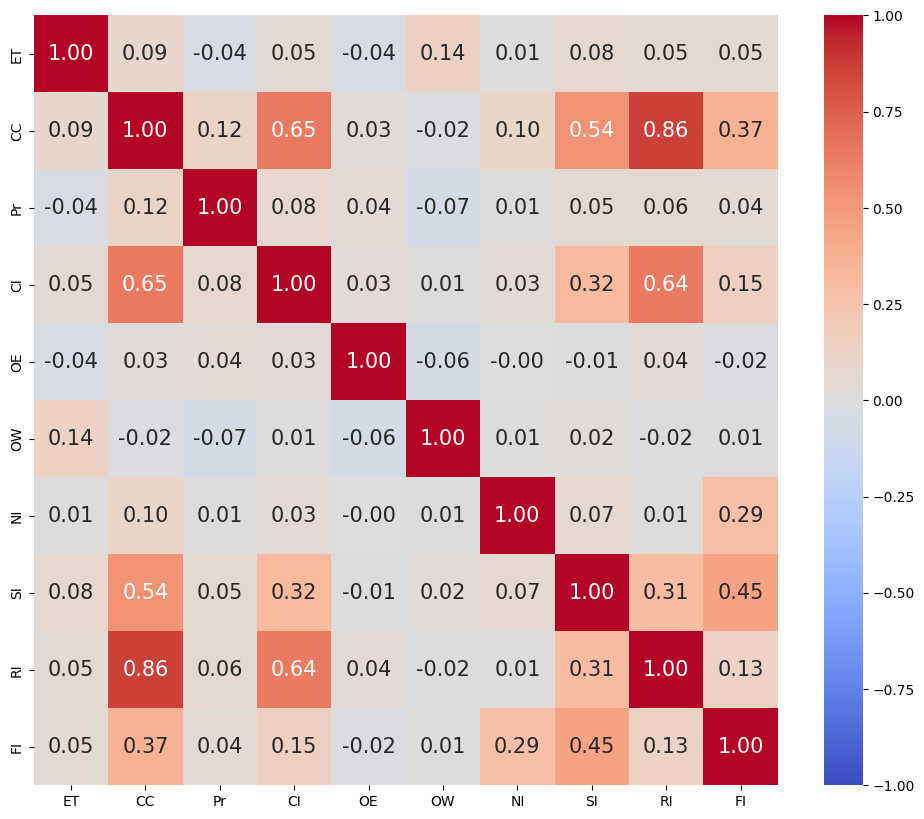

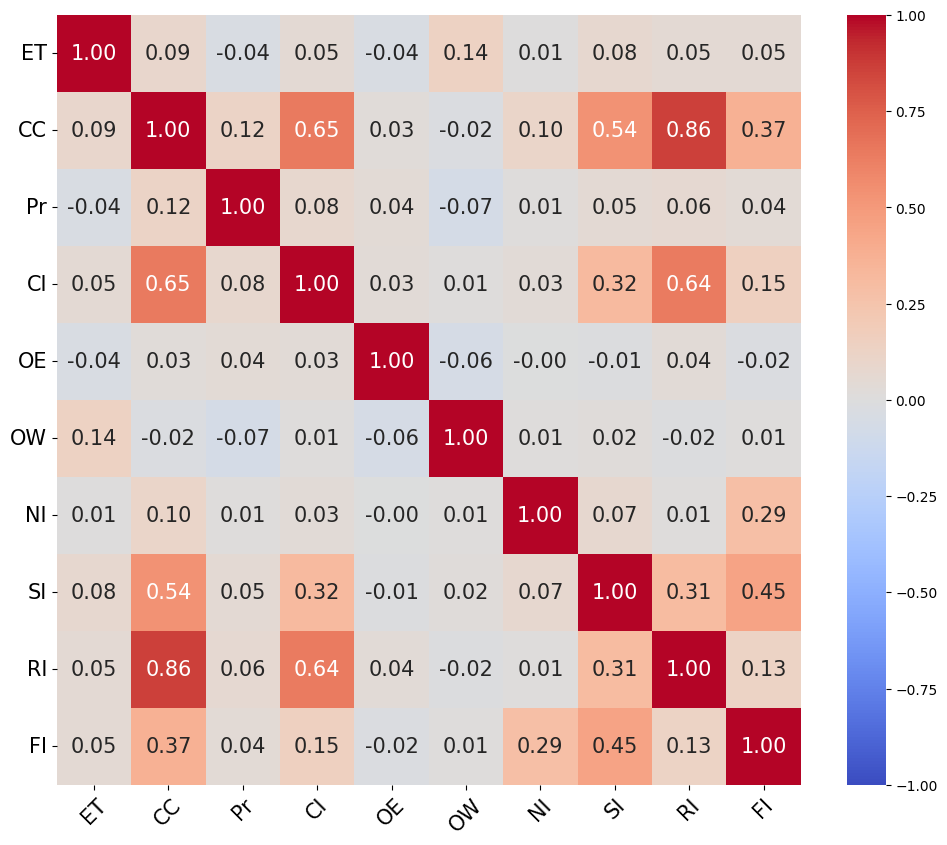

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# plot heatmap for feature variables
corr = df.corr()
plt.figure(figsize=[12,10])
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,annot_kws={"size":15})
#plt.xticks(rotation=60)
import matplotlib.pyplot as plt
import seaborn as sns
# plot heatmap for feature variables
corr = df.corr()
plt.figure(figsize=[12,10])
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,annot_kws={"size":15})
#plt.xticks(rotation=60)
#plt.title("Heatmap of Correlation Coefficient for Bug Feature Variables", size=10);
plt.xticks(rotation=45,size=15)
plt.yticks(rotation=0, size=15)
#plt.title("Heatmap of Correlation Coefficient for Bug Feature Variables", size=14);

#plt.savefig('corrplot-openstack.png', bbox_inches='tight', pad_inches=0.0)


Structural Causal Model



Stage I. Specify the causal graph

In [5]:
import networkx as nx
causal_graph = nx.DiGraph([('OW', 'ET'), ('RI', 'ET'), ('RI', 'CC'),('OE','ET'),('CC','ET'),('SI','RI'),('NI','CC')])

In [6]:
from dowhy import CausalModel, gcm
import pandas as pd

Stage II. Build graphical causal model

In [7]:
# Build Structural causal model on top of the causal graph
from dowhy import gcm
causal_model = gcm.StructuralCausalModel(causal_graph)

In [8]:
# Set causal mechanisms for each node
causal_model.set_causal_mechanism('OW', gcm.EmpiricalDistribution())
causal_model.set_causal_mechanism('SI', gcm.EmpiricalDistribution())
causal_model.set_causal_mechanism('NI', gcm.EmpiricalDistribution())
causal_model.set_causal_mechanism('RI',  gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor()))
causal_model.set_causal_mechanism('ET', gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor()))
causal_model.set_causal_mechanism('CC', gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor()))
causal_model.set_causal_mechanism('OE', gcm.EmpiricalDistribution())

In [9]:
# Now fit the model
gcm.fit(causal_model, df)

Fitting causal mechanism of node NI: 100%|██████████| 7/7 [00:00<00:00, 154.80it/s]


Test permutations of given graph: 100%|██████████| 50/50 [01:12<00:00,  1.46s/it]


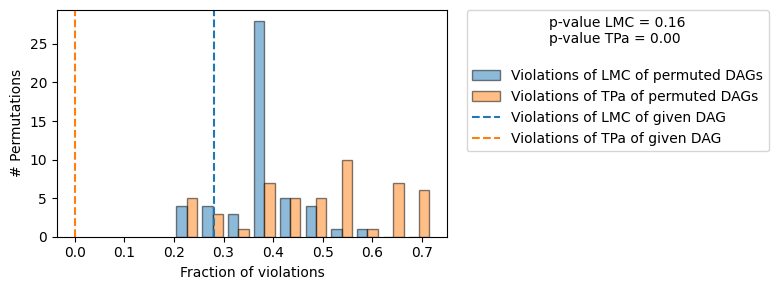

Evaluated the performance of the causal mechanisms and the invertibility assumption of the causal mechanisms and the overall average KL divergence between generated and observed distribution and the graph structure. The results are as follows:

==== Evaluation of Causal Mechanisms ====
The used evaluation metrics are:
- KL divergence (only for root-nodes): Evaluates the divergence between the generated and the observed distribution.
- Mean Squared Error (MSE): Evaluates the average squared differences between the observed values and the conditional expectation of the causal mechanisms.
- Normalized MSE (NMSE): The MSE normalized by the standard deviation for better comparison.
- R2 coefficient: Indicates how much variance is explained by the conditional expectations of the mechanisms. Note, however, that this can be misleading for nonlinear relationships.
- F1 score (only for categorical non-root nodes): The harmonic mean of the precision and recall indicating the goodness of the under

In [10]:
print(gcm.evaluate_causal_model(causal_model, df))

In [14]:
labels = [f'{col}' for i, col in enumerate(df.columns)]
data = df.to_numpy()

# Visualization using pydot
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io



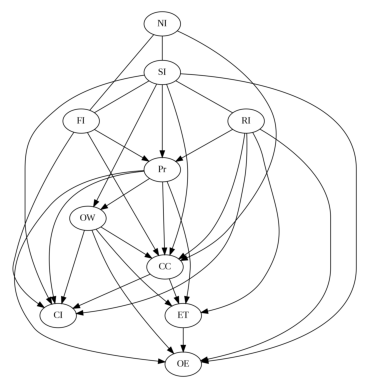

In [15]:
from causallearn.search.ScoreBased.GES import ges

# default parameters
Record = ges(df)

# Visualization using pydot
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

pyd = GraphUtils.to_pydot(Record['G'], labels=labels)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.axis('off')
plt.imshow(img)
plt.show()

# or save the graph
pyd.write_png('Openstack_GES.png')

### GES Score Settings
The `ges` function was called with default parameters:
```python
Record = ges(df)
```
To see the default parameters, you can check the `causallearn` documentation or inspect the function signature. Commonly, these include parameters for the score function (e.g., BIC, BDeu), penalty functions, and convergence criteria.

### Software Versions
Here are the versions of the key libraries used in this notebook:

In [21]:
print(f"dowhy version: {dowhy.__version__}")
import causallearn
import importlib.metadata
print(f"causallearn version: {importlib.metadata.version('causal-learn')}")
print(f"numpy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"networkx version: {nx.__version__}")
import matplotlib
print(f"matplotlib version: {matplotlib.__version__}")
import seaborn
print(f"seaborn version: {seaborn.__version__}")

dowhy version: 0.0.0
causallearn version: 0.1.4.7
numpy version: 2.0.2
pandas version: 2.2.2
networkx version: 3.6.1
matplotlib version: 3.10.0
seaborn version: 0.13.2


### Random Seed Controls
The random seed for NumPy was set at the beginning of the notebook:
```python
np.random.seed(0)
```
This ensures reproducibility for operations that rely on NumPy's random number generation.

In [26]:
#bootstrap-based edge stability analysis
import numpy as np
import pandas as pd
from sklearn.utils import resample
from causallearn.search.ScoreBased.GES import ges

# Load your dataset (replace with actual file or DataFrame)
# Example: if you have a CSV file
#X = pd.read_csv("your_dataset.csv").values   # shape: (n_samples, n_features)

n_bootstrap = 100   # number of bootstrap iterations
#n_vars = X.shape[1]
n_vars = len(df.columns)
edge_counts = np.zeros((n_vars, n_vars))

for i in range(n_bootstrap):
    # Bootstrap resample (same number of rows, sampled with replacement)
    #X_resampled = resample(X, replace=True, n_samples=len(X))
    data_resampled = resample(df, replace=True, n_samples=len(df))
    X_resampled = data_resampled.to_numpy()

    # Run GES on resampled dataset
    ges_result = ges(X_resampled)
    adj_matrix = ges_result['G'].graph  # adjacency matrix (numpy array)

    # Count edges
    edge_counts += adj_matrix

# Compute stability scores (fraction of times each edge appears)
edge_stability = edge_counts / n_bootstrap

print("Edge stability matrix (values between 0 and 1):")
print(edge_stability)


Edge stability matrix (values between 0 and 1):
[[ 0.    0.96  1.    0.    0.06  1.    0.15  0.01  1.    0.12]
 [-0.96  0.    0.98 -0.68  0.01  0.97  0.5   0.94  1.    1.  ]
 [-1.   -0.98  0.   -0.45 -0.42 -0.34 -0.04  0.12  0.2   0.46]
 [ 0.    0.64  0.45  0.   -0.01  0.92  0.02  0.66  0.94  0.74]
 [-0.08 -0.01  0.24  0.01  0.    0.2   0.    0.42  0.2   0.05]
 [-1.   -0.97 -0.18 -0.92 -0.72  0.   -0.18 -0.16 -0.04 -0.01]
 [-0.15 -0.5   0.04 -0.02  0.    0.1   0.   -0.22  0.14 -0.24]
 [-0.01 -0.94 -0.24 -0.7  -0.46 -0.08 -0.24  0.    0.04 -0.78]
 [-1.   -1.   -0.74 -0.96 -0.36 -0.02 -0.2  -0.36  0.   -0.22]
 [-0.12 -1.   -0.48 -0.74 -0.07 -0.05 -0.28 -0.12  0.2   0.  ]]


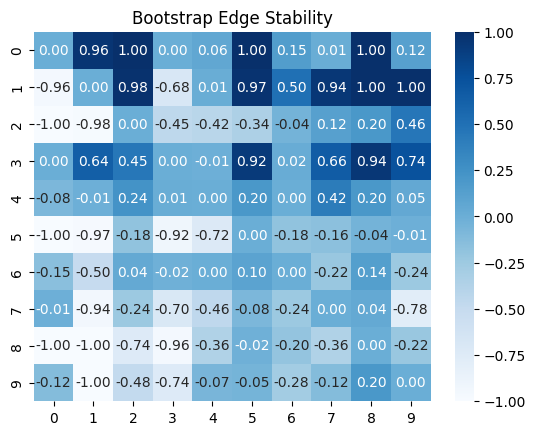

In [27]:
#Visualize Stability
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(edge_stability, annot=True, cmap="Blues", fmt=".2f")
plt.title("Bootstrap Edge Stability")
plt.show()

In [34]:
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 3 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.

Global Interpretability with SHAP Summary Plot

In [31]:
!pip install shap
import shap

shap.initjs()

SHAP

In [42]:
import xgboost
from sklearn.model_selection import train_test_split

In [43]:
features = ['CC', 'OE', 'OW', 'NI', 'SI', 'RI']
X_train, X_test, y_train, y_test = train_test_split(df[features], df.ET, test_size=0.2)

In [44]:
y_train

,ET
13104,2929.8669
17049,146.1628
5757,276.7603
15084,1033.8264
4475,149.2017
...,...
8599,23.3831
24569,409.5603
3893,784.4689
13929,1455.0406


In [45]:
import shap
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import dowhy


# Train a model
model = xgboost.XGBRegressor()
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Display the summary_plot using SHAP values and testing set.

/tmp/ipykernel_3701/238825501.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


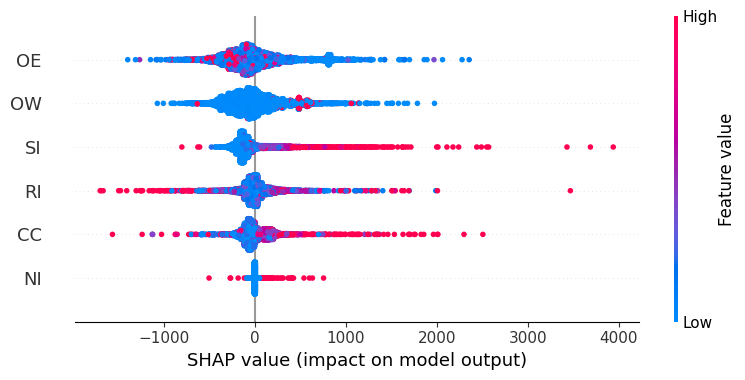

<Figure size 640x480 with 0 Axes>

In [47]:
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
plt.savefig('SHAP_Openstack.png')

In [61]:
# Use DoWhy to model causal relationships
causal_model_os_RI = dowhy.CausalModel(
    data=df,
    treatment="RI",
    outcome="ET",
    graph=causal_graph
)

In [62]:
# Identify causal effect
identified_estimand_os_RI = causal_model_os_RI.identify_effect()

In [63]:
# Estimate causal effect
causal_estimate_os_RI = causal_model_os_RI.estimate_effect(
    identified_estimand_os_RI,
    method_name="backdoor.linear_regression"
)

In [66]:
print("Causal effect of RI on ET:", causal_estimate_os_RI.value)

ri_index = X_test.columns.get_loc('RI')
causal_shap_values[:, ri_index] = shap_values[:, ri_index] * causal_estimate_os_RI.value

#print("Causal SHAP values (approx):", causal_shap_values[:5])

Causal effect of RI on ET: 8.04664207172209


/tmp/ipykernel_3701/2496795222.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(causal_shap_values, X_test)


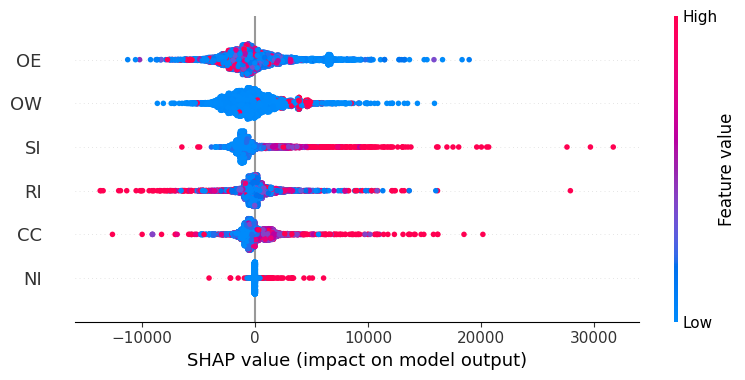

In [51]:
shap.summary_plot(causal_shap_values, X_test)

In [53]:
shap_values = explainer.shap_values(X_test)
print(shap_values)

[[ -70.891  -30.946 -297.226   -1.691 -129.405   13.093]
 [ -35.64  -117.685  -82.432   -3.243 -181.831   35.029]
 [-321.509    9.391 -167.136    6.123 -133.455  275.092]
 ...
 [ -63.315 -250.373 -193.204   -2.593 -151.05    54.345]
 [-286.844  204.872 -133.802   -0.763 -214.361  322.977]
 [ -65.28  -135.297   14.24     0.449  -95.725   -7.793]]


In [58]:
# Use DoWhy to model causal relationships for Openstack
causal_model_os_CC = dowhy.CausalModel(
    data=df,
    treatment="CC",
    outcome="ET",
    graph=causal_graph
)
identified_estimand_os_CC = causal_model_os_CC.identify_effect()
causal_estimate_os_CC = causal_model_os_CC.estimate_effect(
    identified_estimand_os_CC,
    method_name="backdoor.linear_regression"
)
print("Causal effect of CC on ET for Openstack:", causal_estimate_os_CC.value)

theta_os_CC = causal_estimate_os_CC.value
se_os_CC = 0.0
var_os_CC = 0.0
if theta_os_CC != 0:
    try:
        se_os_CC= causal_estimate_os_CC.get_standard_error()
        var_os_CC= se_os_CC**2
    except AttributeError:
        print("Warning: Causal estimate for CC has no 'estimator' attribute. Standard error and variance set to 0.")


# Adjust SHAP values with causal effect for Openstack

cc_index_os = X_test.columns.get_loc('CC')
causal_shap_values[:, cc_index_os] = shap_values[:, cc_index_os] * causal_estimate_os_CC.value
#causal_shap_values_os[:, 0] = shap_values_os[:, 0] * causal_estimate.value

Causal effect of CC on ET for Openstack: 198.08389162333765


Refutation Tests for CC on ET

In [75]:
refutel_common_cause_CC = causal_model_os_CC.refute_estimate(identified_estimand_os_CC, causal_estimate_os_CC, "random_common_cause")
print(refutel_common_cause_CC)

Refute: Add a random common cause
Estimated effect:198.08389162333765
New effect:198.07694352964853
p value:0.96



In [ ]:
refutel_data_subset_CC = causal_model_os_CC.refute_estimate(identified_estimand_os_CC, causal_estimate_os_CC, "data_subset_refuter")
print(refutel_data_subset_CC)

Similarly find the causal shap values for OW, Pr, SI, FI

In [68]:
# Initialize causal_shap_values_all with the original SHAP values from XGBoost model
causal_shap_values_all = shap_values.copy()

# Get correct feature indices from X_test (XGBoost features)
ri_index = X_test.columns.get_loc('RI')
cc_index = X_test.columns.get_loc('CC')
#ow_index = X_test.columns.get_loc('OW')
#pr_index = X_test.columns.get_loc('Pr')
#si_index = X_test.columns.get_loc('SI')
#fi_index = X_test.columns.get_loc('FI')

# Apply causal adjustments cumulatively
if causal_estimate_os_RI.value is not None: # For RI
    causal_shap_values_all[:, ri_index] = shap_values[:, ri_index] * causal_estimate_os_RI.value
else:
    print("Warning: Causal effect for RI on ET could not be estimated. SHAP values for RI will not be causally adjusted.")

if causal_estimate_os_CC.value is not None: # For CC
    causal_shap_values_all[:, cc_index] = shap_values[:, cc_index] * causal_estimate_os_CC.value
else:
    print("Warning: Causal effect for CC on ET could not be estimated. SHAP values for CC will not be causally adjusted.")

#if causal_estimate_os_OW.value is not None: # For OW
 #   causal_shap_values_all[:, ow_index] = shap_values[:, ow_index] * causal_estimate_os_OW.value
#else:
 #   print("Warning: Causal effect for OW on ET could not be estimated. SHAP values for OW will not be causally adjusted.")

#if causal_estimate_os_Pr.value is not None: # For Pr
 #   causal_shap_values_all[:, pr_index] = shap_values[:, pr_index] * causal_estimate_os_Pr.value
#else:
  #  print("Warning: Causal effect for Pr on ET could not be estimated. SHAP values for Pr will not be causally adjusted.")

print("Causal SHAP values adjusted for RI, CC, OW, SI, FI and Pr.")

Causal SHAP values adjusted for RI, CC, OW, and Pr.


/tmp/ipykernel_3701/2963113315.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(causal_shap_values_all, X_test, plot_type="dot", show=False)


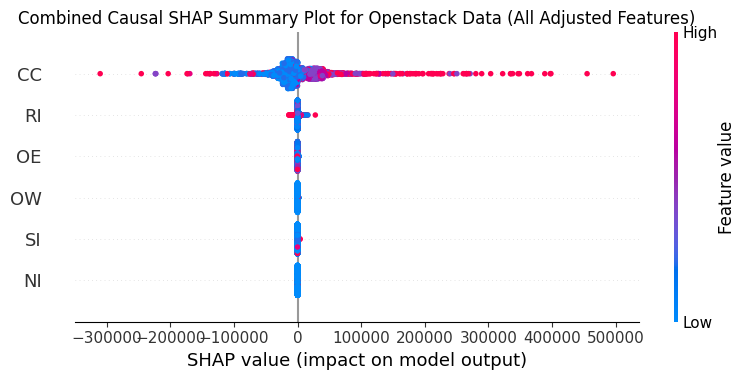

Combined Causal SHAP summary plot displayed for comparison.


In [69]:
# Display the Combined Causal SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(causal_shap_values_all, X_test, plot_type="dot", show=False)
plt.title('Combined Causal SHAP Summary Plot for Openstack Data (All Adjusted Features)')
plt.tight_layout()
plt.show()
print("Combined Causal SHAP summary plot displayed for comparison.")

In [70]:
# Calculate mean SHAP values
mean_shap_os = pd.Series(shap_values.mean(axis=0), index=X_test.columns)
mean_causal_shap_values = pd.Series(causal_shap_values_all.mean(axis=0), index=X_test.columns)

print("Mean Original SHAP Values:")
print(mean_shap_os)
print("\nMean Causal SHAP Values:")
print(mean_causal_shap_values)

Mean Original SHAP Values:
CC    11.081786
OE    -6.674439
OW    -6.803354
NI     0.014841
SI   -16.132483
RI     5.493425
dtype: float32

Mean Causal SHAP Values:
CC    2195.121582
OE      -6.674439
OW      -6.803354
NI       0.014841
SI     -16.132483
RI      44.203690
dtype: float32


In [71]:
# Function to normalize SHAP values for a single dataset
def normalize_shap_series(series):
    abs_series = series.abs()
    # Handle cases where sum might be zero to avoid division by zero
    if abs_series.sum() == 0:
        return series * 0 # Return series of zeros if sum is zero
    return abs_series / abs_series.sum()

# Normalize mean SHAP values for each dataset
normalized_mean_shap_os = normalize_shap_series(mean_shap_os)
#normalized_mean_shap_mz = normalize_shap_series(mean_shap_mz)
#normalized_mean_shap_ec = normalize_shap_series(mean_shap_ec)

In [ ]:
# Normalize mean causal SHAP values
normalized_mean_causal_shap_values = normalize_shap_series(mean_causal_shap_values)

print("Normalized Mean Original SHAP Values (Openstack):")
display(normalized_mean_shap_os)
print("\nNormalized Mean Causal SHAP Values (Openstack):")
display(normalized_mean_causal_shap_values)


--- Global Feature Importance (Mean Across Openstack, Mozilla, and Eclipse - Normalized) ---


,0
SI,0.349185
CC,0.239864
OW,0.147258
OE,0.144467
RI,0.118904
NI,0.000321


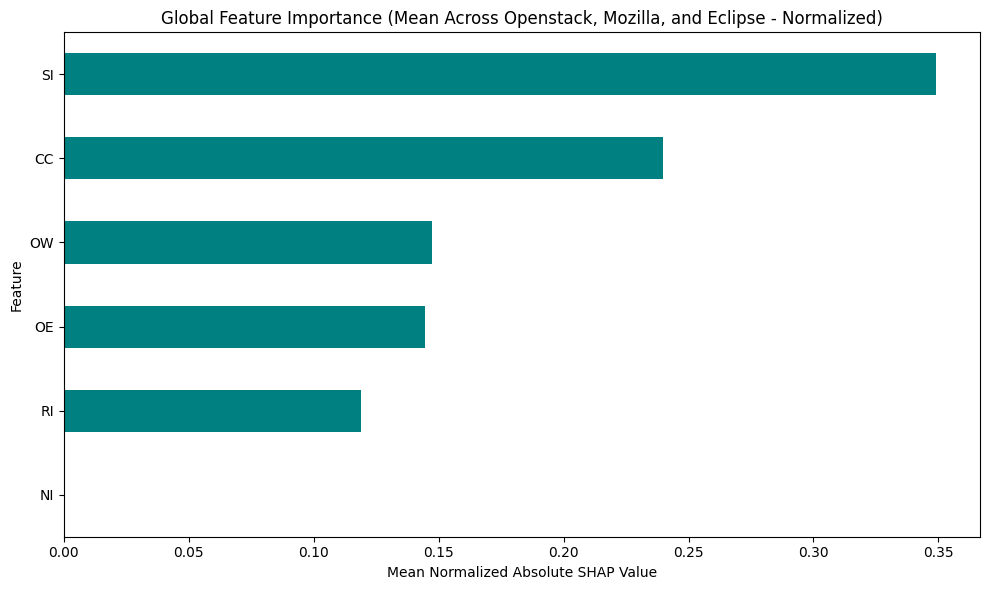

In [77]:
import matplotlib.pyplot as plt
# Combine the normalized mean causal SHAP values from Openstack, Mozilla, and Eclipse into a single DataFrame
all_models_mean_shap = pd.DataFrame({
    'Openstack Normalized Mean': normalized_mean_shap_os,
    'Mozilla Normalized Mean': normalized_mean_shap_mz,
    'Eclipse Normalized Mean': normalized_mean_shap_ec
})

# Calculate the overall mean importance for each feature across the available models
global_mean_importance = all_models_mean_shap.mean(axis=1).sort_values(ascending=False)

print("\n--- Global Feature Importance (Mean Across Openstack, Mozilla, and Eclipse - Normalized) ---")
display(global_mean_importance)

# Visualize the global feature importance
plt.figure(figsize=(10, 6))
global_mean_importance.plot(kind='barh', color='teal')
plt.title('Global Feature Importance (Mean Across Openstack, Mozilla, and Eclipse - Normalized)')
plt.xlabel('Mean Normalized Absolute SHAP Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()